## 1. Problem Statement

Customer churn is a major challenge for telecom companies as it directly impacts revenue and growth.

The goal of this analysis is to:
- Identify key factors driving customer churn
- Analyze customer behavior patterns
- Provide actionable insights to improve customer retention

## 2. Importing Libraries

In [1]:
! pip install pandas numpy matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 3. Loading the CSV file

In [3]:
df = pd.read_csv("../data/telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Understanding the Structure 

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 5. Data Cleaning

Fixing TotalCharges column 

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Well here we see that there are 11 missing/null values in TotalCharhges column. that is 0.15% of the data. Before dropping any rows, lets see why they are missing! 

In [9]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


With this output we can conclude that TotalCharges is missing because they haven’t been billed yet (Tenure is 0 for all these values)

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The missing values in TotalCharges correspond to new customers with zero tenure. Since they represent a very small portion of the dataset (~0.15%) and lack sufficient billing history, these rows were removed to maintain data consistency.

In [12]:
df.duplicated().sum()

np.int64(0)


Understanding Feature Types

In [13]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Data Cleaning Summary
- Converted `TotalCharges` to numeric
- Removed missing values
- Checked for duplicate records

## 6. Univariate Analysis

In [14]:

sns.set_theme(style="whitegrid")

primary_color = "#1E3A8A"   # royal blue
secondary_color = "#93C5FD" # light blue

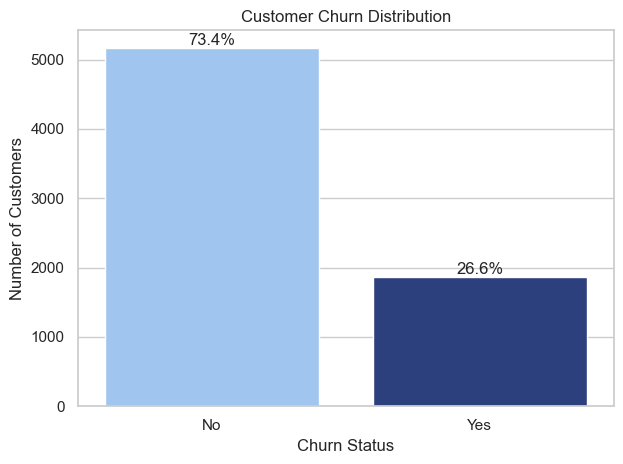

In [15]:
ax = sns.countplot(
    x="Churn",
    hue="Churn",
    data=df,
    palette={"No": secondary_color, "Yes": primary_color},
    legend=False
)

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

- The dataset is imbalanced, with a higher number of non-churned customers (~73%) compared to churned customers (~27%).
- Although most customers are retained, the churn rate is still significant and represents a key business concern.

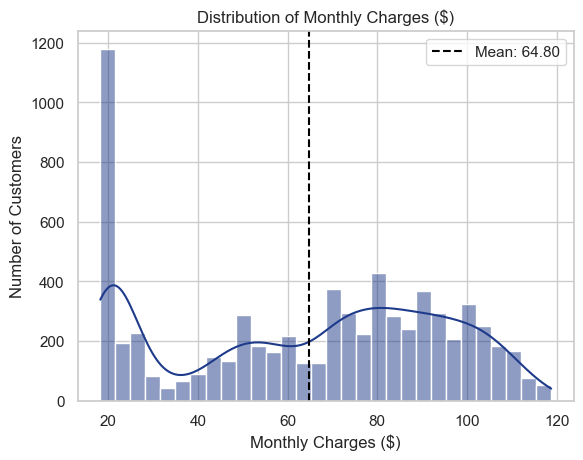

In [16]:
mean_val = df["MonthlyCharges"].mean()

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color=primary_color)

plt.axvline(mean_val, color="black", linestyle="--", label=f"Mean: {mean_val:.2f}")

plt.title("Distribution of Monthly Charges ($)")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

- The distribution of monthly charges is bimodal, indicating the presence of two distinct customer segments.
- One group consists of low-paying customers, while another consists of customers with higher monthly charges.
- This suggests variation in service plans and customer value, which may influence churn behavior.

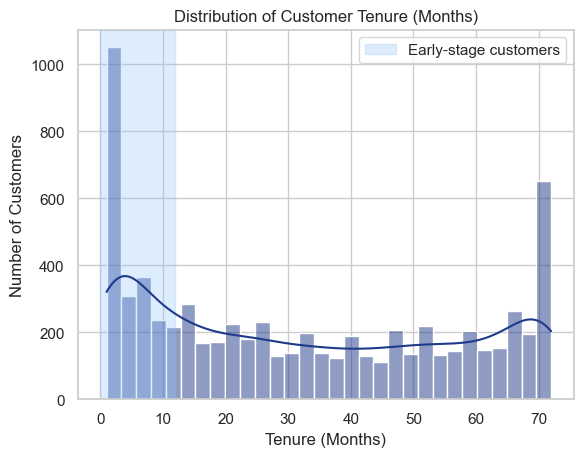

In [17]:
sns.histplot(df["tenure"], bins=30, kde=True, color=primary_color)

plt.axvspan(0, 12, color=secondary_color, alpha=0.3, label="Early-stage customers")

plt.title("Distribution of Customer Tenure (Months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

- The tenure distribution shows a high concentration of customers with low tenure, indicating a large number of new customers.
- There is also a significant number of long-term customers with high tenure.
- This suggests that churn is likely higher among new customers, while long-term customers tend to stay.

In [18]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


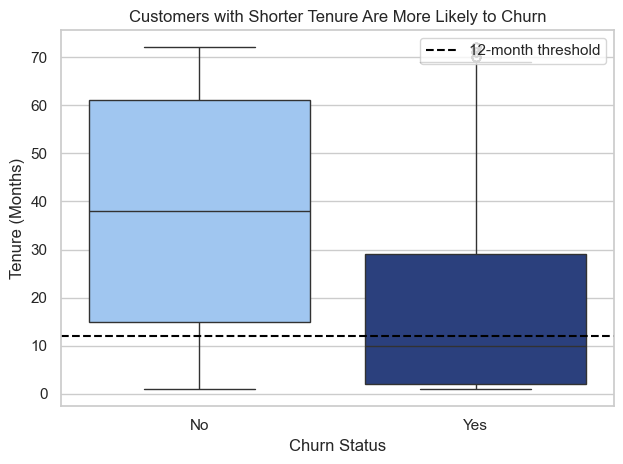

In [19]:
sns.boxplot(
    x="Churn",
    y="tenure",
    hue="Churn",
    data=df,
    palette={"No": secondary_color, "Yes": primary_color},
    legend=False
)

plt.axhline(12, color="black", linestyle="--", label="12-month threshold")

plt.title("Customers with Shorter Tenure Are More Likely to Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

- Customers with low tenure are significantly more likely to churn compared to long-term customers.
- The median tenure for churned customers is much lower than for retained customers.
- This confirms that churn is concentrated in the early stages of the customer lifecycle.
- Improving early customer engagement and onboarding could reduce churn significantly.

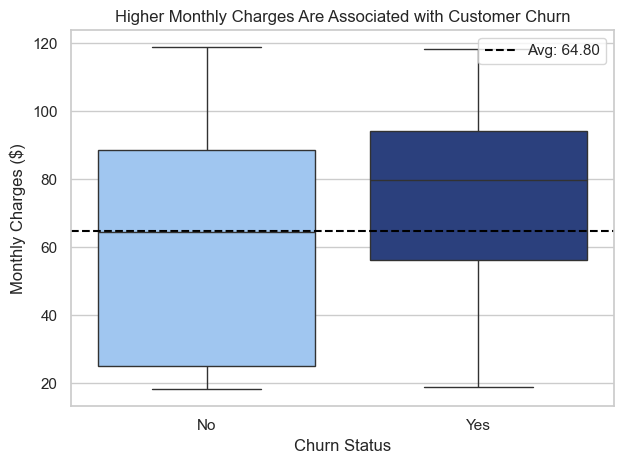

In [20]:
avg_charge = df["MonthlyCharges"].mean()

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    data=df,
    palette={"No": secondary_color, "Yes": primary_color},
    legend=False
)

plt.axhline(avg_charge, color="black", linestyle="--", label=f"Avg: {avg_charge:.2f}")

plt.title("Higher Monthly Charges Are Associated with Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges ($)")

plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

- Customers who churn tend to have higher monthly charges compared to those who stay.
- The median monthly charge for churned customers is significantly higher.
- Although there is some overlap, the overall trend indicates that higher-paying customers are at greater risk of churn.
- This suggests that pricing, perceived value, or service satisfaction may influence churn behavior.

# 7. Bivariate Analysis

In [21]:
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index")

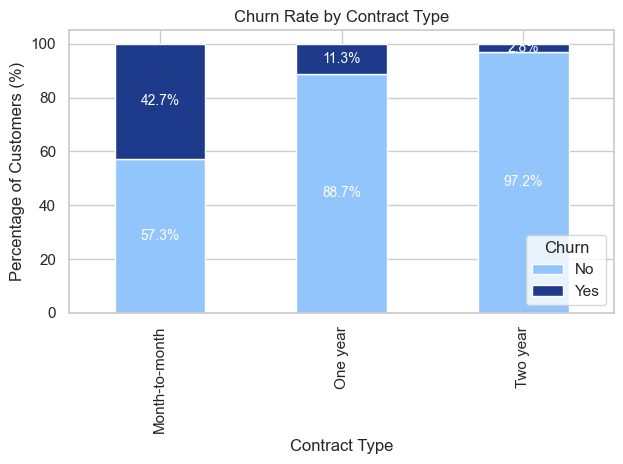

In [22]:
ax = (ct * 100).plot(
    kind="bar",
    stacked=True,
    color=[secondary_color, primary_color]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", color="white", fontsize=10)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers (%)")
#plt.legend(title="Churn", loc="upper right")

plt.tight_layout()
plt.show()

- Customers on month-to-month contracts have the highest churn rate, indicating low commitment.
- Customers with one-year and two-year contracts show significantly lower churn.
- Long-term contracts act as a retention mechanism, reducing the likelihood of customers leaving.
- This aligns with earlier findings that churn is concentrated among customers with low tenure.
- Encouraging customers to switch to long-term contracts could significantly improve retention.

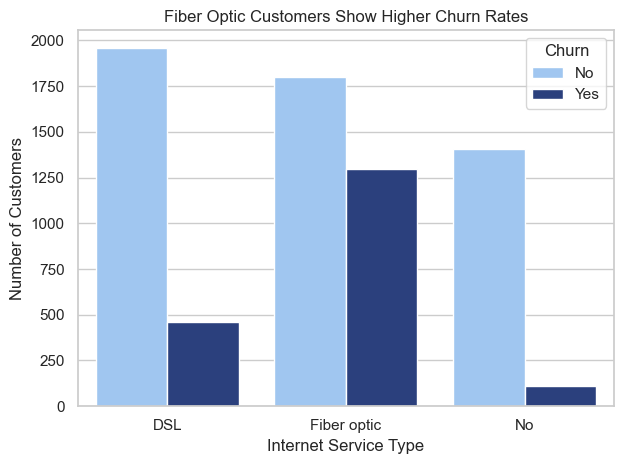

In [23]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df,
    palette={"No": secondary_color, "Yes": primary_color}
)

plt.title("Fiber Optic Customers Show Higher Churn Rates")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", loc="upper right")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

- Customers using Fiber optic internet have the highest churn rate among all service types.
- DSL and customers without internet service show significantly lower churn.
- Despite being a premium service, Fiber optic users are more likely to leave, possibly due to higher costs or unmet expectations.
- This indicates that high-value customers may also be at higher risk of churn.

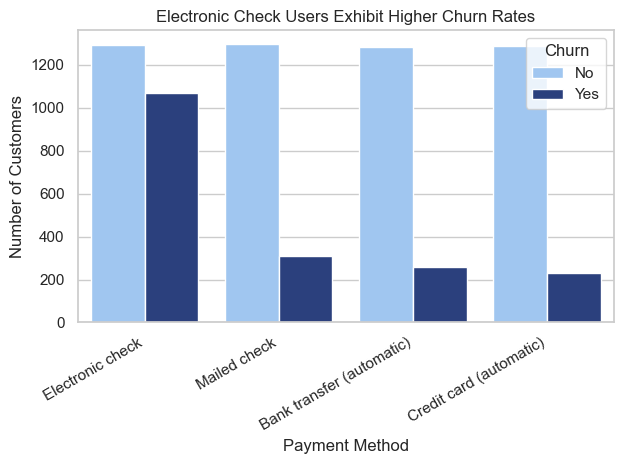

In [24]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df,
    palette={"No": secondary_color, "Yes": primary_color}
)

plt.title("Electronic Check Users Exhibit Higher Churn Rates")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn", loc="upper right")

plt.tight_layout()
plt.show()

- Customers using electronic check have the highest churn rate among all payment methods.
- Customers using automatic payment methods (credit card and bank transfer) show the lowest churn.
- This suggests that automated payments improve customer retention by reducing friction and increasing commitment.
- Encouraging customers to adopt auto-payment methods could help reduce churn.

*Customer Profile*: New customers on month-to-month contracts, paying higher charges (often for premium services like fiber optic), and using manual payment methods are the most likely to churn.

# 8. Correlation Heatmap

In [25]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_numeric"]

In [28]:
df["Churn_numeric"] = df["Churn"].map({"Yes": 1, "No": 0})

In [29]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created
df["TotalCharges"].isnull().sum()

np.int64(0)

In [30]:
df = df.dropna()

In [31]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_numeric'],
      dtype='str')


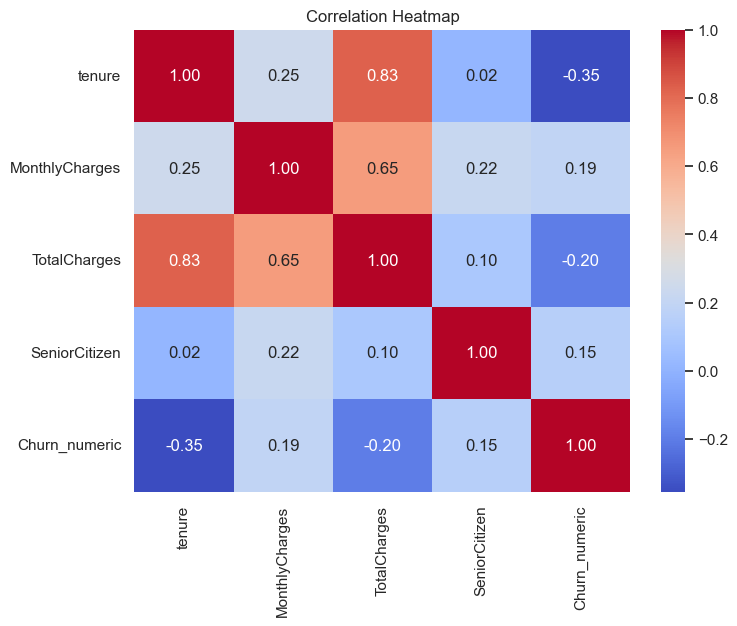

In [32]:
ccorr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_numeric"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

🔍 Correlation Analysis Insights

From the correlation heatmap:

- `tenure` has the strongest negative correlation with churn (-0.35), meaning customers with longer tenure are less likely to churn.
- `MonthlyCharges` shows a positive correlation (0.19), indicating higher charges increase churn likelihood.
- `TotalCharges` is negatively correlated (-0.20), but it is strongly related to tenure (0.83), so it does not provide independent insight.
- `SeniorCitizen` has a weak positive correlation (0.15), suggesting a minor impact on churn.

Key Insight:
Customer lifecycle (tenure) and pricing (monthly charges) are the primary drivers of churn.

# 9. Top Factors Influencing Churn (Correlation-Based)

In [33]:
churn_corr = corr_matrix["Churn_numeric"].sort_values(ascending=False)
churn_corr

Churn_numeric     1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_numeric, dtype: float64

In [34]:
top_corr = churn_corr.drop("Churn_numeric")
top_corr

MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_numeric, dtype: float64

In [35]:
top_corr_abs = df[corr_cols].corr()["Churn_numeric"].drop("Churn_numeric").abs().sort_values(ascending=False)
top_corr_abs

tenure            0.354049
TotalCharges      0.199484
MonthlyCharges    0.192858
SeniorCitizen     0.150541
Name: Churn_numeric, dtype: float64

**Top Factors Influencing Churn**

Based on correlation analysis (absolute values):

1. **tenure (0.35)** – strongest factor  
   - Customers with shorter tenure are more likely to churn  

2. **MonthlyCharges (0.19)** – key pricing factor  
   - Higher monthly charges increase churn likelihood  

3. **TotalCharges (0.19)** – dependent factor  
   - Strongly correlated with tenure, so it does not provide independent insight  

4. **SeniorCitizen (0.15)** – minor influence  
   - Slightly higher churn among senior citizens  

**Key Takeaway:**
Customer lifecycle (tenure) and pricing (monthly charges) are the most important drivers of churn.

## 10. Key Observations section

## 🔑 Key Observations

- Customers on month-to-month contracts have significantly higher churn, indicating low long-term commitment.
- Customers with lower tenure are the most likely to churn, highlighting early lifecycle risk.
- Higher monthly charges increase churn likelihood, indicating pricing sensitivity.
- Customers using electronic check payments have higher churn compared to automatic payment methods.
- Tenure and MonthlyCharges are the strongest drivers of churn, while TotalCharges is not an independent factor due to its high correlation with tenure.

## 💡 Business Recommendations

- Incentivize customers to shift from month-to-month to long-term contracts (annual or two-year plans).
- Focus retention efforts on early-stage customers (first 6–12 months).
- Review pricing strategies for high monthly charge segments to improve perceived value.
- Investigate churn among fiber optic users to identify service or expectation gaps.
- Promote automatic payment methods (credit card/bank transfer) to improve retention.

## 11. Feature Engineering

In [36]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

In [37]:
df["MonthlyCharges_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 70, 120],
    labels=["Low", "Medium", "High"]
)

In [38]:
services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df["TotalServices"] = (df[services] == "Yes").sum(axis=1)

In [39]:
df["HighRisk"] = (
    (df["tenure"] < 12) &
    (df["MonthlyCharges"] > 70) &
    (df["Contract"] == "Month-to-month")
)

# 12. Segment Analysis

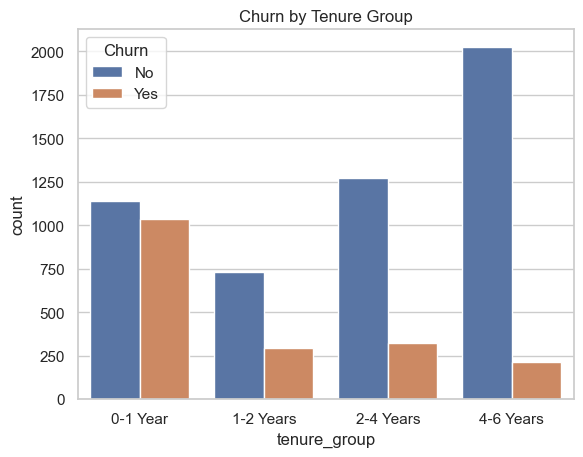

In [40]:
sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.title("Churn by Tenure Group")
plt.show()

1. Customers in the 0–1 year tenure group show the highest churn rates, while churn decreases significantly as tenure increases.
2. This indicates that the early stage of the customer lifecycle is the most critical for retention.

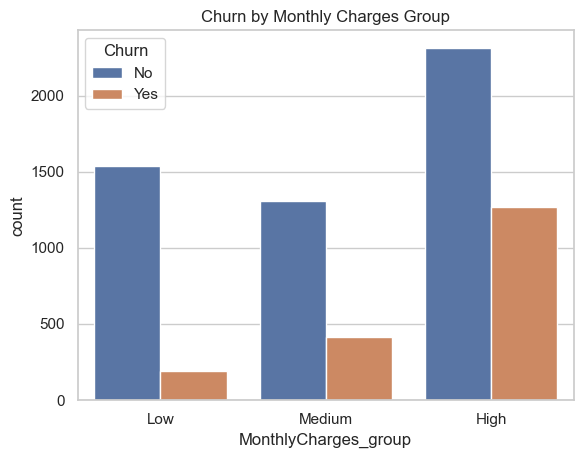

In [41]:
sns.countplot(x="MonthlyCharges_group", hue="Churn", data=df)
plt.title("Churn by Monthly Charges Group")
plt.show()

1. Customers with high monthly charges exhibit significantly higher churn compared to those with lower charges.
2. This suggests pricing sensitivity and possible dissatisfaction with perceived value.

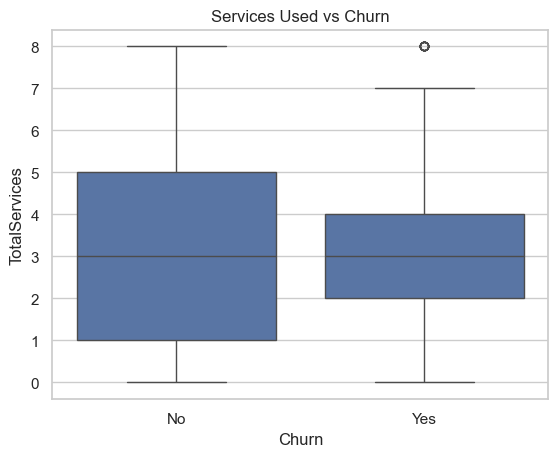

In [42]:
sns.boxplot(x="Churn", y="TotalServices", data=df)
plt.title("Services Used vs Churn")
plt.show()

1. The number of services used does not show a strong relationship with churn.
2. This indicates that churn is not primarily driven by the number of services, but rather by factors like pricing and contract type.

In [43]:
df.groupby("HighRisk")["Churn_numeric"].mean()

HighRisk
False    0.209553
True     0.695332
Name: Churn_numeric, dtype: float64

1. Customers identified as high-risk (low tenure, high charges, month-to-month contracts) have a churn rate of approximately 69%, compared to ~20% for others.
2. This segment is over 3x more likely to churn and represents a critical target for retention strategies.

# 13. Churn Profile

High-Risk Customer Profile

Customers most likely to churn typically have:

- Short tenure (less than 1 year)
- High monthly charges
- Month-to-month contracts
- Electronic check payment method
- Fiber optic internet service

These customers represent the highest-risk segment and should be prioritized for retention efforts.

# 14. Business Insight Layer

Analytical Insights

Churn is concentrated among new customers, indicating potential issues with onboarding, expectation setting, or early customer experience.

Higher monthly charges suggest that customers may not perceive sufficient value relative to cost, leading to dissatisfaction.

Flexible contract types (month-to-month) reduce commitment, making it easier for customers to leave.

Churn is driven by a combination of lifecycle stage, pricing pressure, and lack of long-term commitment.

# 15. Building Churn Score

In [44]:
df["ChurnScore"] = (
    (df["tenure"] < 12).astype(int) +
    (df["MonthlyCharges"] > 70).astype(int) +
    (df["Contract"] == "Month-to-month").astype(int)
)

In [45]:
df.groupby("ChurnScore")["Churn_numeric"].mean()

ChurnScore
0    0.029354
1    0.127502
2    0.404273
3    0.695332
Name: Churn_numeric, dtype: float64

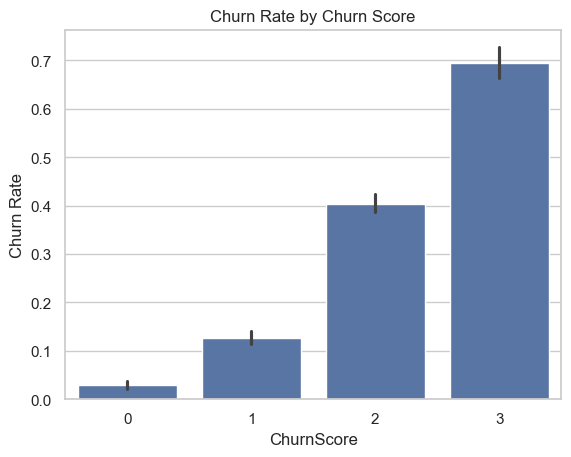

In [46]:
sns.barplot(x="ChurnScore", y="Churn_numeric", data=df)
plt.title("Churn Rate by Churn Score")
plt.ylabel("Churn Rate")
plt.show()

**Churn Risk Scoring**

A churn scoring system was created using three key risk factors:

- Low tenure (< 12 months)
- High monthly charges (> 70)
- Month-to-month contract

Each condition contributes 1 point, resulting in a score from 0 to 3.

**Key Insight**

Churn rate increases sharply with higher churn scores:

- Score 0 → ~3% churn (low risk)
- Score 1 → ~12% churn (moderate risk)
- Score 2 → ~40% churn (high risk)
- Score 3 → ~69% churn (very high risk)

Customers with a score of 3 are over **20x more likely to churn** compared to low-risk customers.

**Business Impact**

This scoring system can be used to:
- Identify high-risk customers in advance
- Prioritize retention efforts
- Allocate resources efficiently to reduce churn

## 16. Churn Prediction Model (Logistic Regression)

In [47]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "SeniorCitizen"
]

In [48]:
target = "Churn_numeric"

In [49]:
X = df[features]
y = df[target]

In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
y_pred = model.predict(X_test_scaled)

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249

Confusion Matrix:
[[917 116]
 [183 191]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
importance


,Feature,Coefficient
2,TotalCharges,0.759750
9,InternetService_Fiber optic,0.473619
7,PaymentMethod_Electronic check,0.181418
3,SeniorCitizen,0.142507
8,PaymentMethod_Mailed check,-0.051592
6,PaymentMethod_Credit card (automatic),-0.051880
1,MonthlyCharges,-0.094363
4,Contract_One year,-0.352899
10,InternetService_No,-0.360332
5,Contract_Two year,-0.667754


In [63]:
importance.to_csv("../outputs/model_results/feature_importance.csv", index=False)

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Value": [0.787, 0.62, 0.51, 0.56]
})

metrics_df.to_csv("../outputs/model_results/model_metrics.csv", index=False)

In [67]:
plt.savefig("../outputs/plots/churn_by_tenure.png")

<Figure size 640x480 with 0 Axes>

In [68]:
plt.savefig("../outputs/plots/churn_score.png")

<Figure size 640x480 with 0 Axes>

In [69]:
plt.savefig("../outputs/plots/churn_by_charges.png")

<Figure size 640x480 with 0 Axes>

**🤖 Churn Prediction Model (Logistic Regression)**

A logistic regression model was trained to predict customer churn using key customer, pricing, contract, payment, and internet service features.

**Model Performance**

- Accuracy: **78.75%**
- Precision (Churn): **0.62**
- Recall (Churn): **0.51**
- F1-score (Churn): **0.56**

**Model Interpretation**

- The model performs reasonably well overall and is more effective at identifying non-churners than churners.
- `tenure` is the strongest churn-reducing factor, confirming that long-term customers are less likely to leave.
- Long-term contracts (`One year`, `Two year`) significantly reduce churn risk.
- `Fiber optic` internet service and `Electronic check` payment method increase churn risk.
- `TotalCharges` appears influential, but it likely overlaps with tenure-related customer lifecycle effects.

**Business Meaning**

The model confirms that churn is primarily influenced by customer lifecycle stage, contract commitment, and pricing/service-related factors. While the model is useful for identifying high-risk customers, recall can be improved further to capture more actual churners.

## 🔍 Key Drivers of Churn (Model-Based)

The model identified the following key factors influencing churn:

### 🔺 Factors Increasing Churn Risk
- Customers using **fiber optic internet** show higher churn risk
- Customers paying via **electronic check** are more likely to churn
- **Senior citizens** show slightly higher churn rates

### 🔻 Factors Reducing Churn Risk
- **Longer tenure** significantly reduces churn likelihood
- Customers on **one-year and two-year contracts** are much less likely to churn

👉 These findings validate earlier EDA insights and highlight the importance of customer lifecycle and contract commitment.

## 📊 Impact Analysis

- High-risk customers (ChurnScore = 3) show a churn rate of ~69%, compared to ~3% for low-risk customers.
- This indicates that high-risk customers are over **20x more likely to churn**.
- The model achieves ~79% accuracy, but captures ~51% of actual churners, indicating room for improvement in identifying all at-risk customers.

👉 Even with moderate recall, the model can significantly improve targeted retention strategies by prioritizing high-risk segments.

## 🔗 Connecting EDA and Model Insights

The model results reinforce patterns observed during EDA:

- Customers with **low tenure** consistently show higher churn risk
- **Month-to-month contracts** remain a key driver of churn
- **Higher monthly charges** contribute to increased churn likelihood
- Payment and service-related factors further influence churn behavior

👉 This alignment between EDA and model results increases confidence in the reliability of the findings.

## 💼 Data-Driven Business Recommendations

### 1. Early Lifecycle Retention Strategy
- Focus on customers within the first 12 months
- Improve onboarding experience and engagement
- Offer targeted incentives during early stages

### 2. Contract Conversion Strategy
- Encourage customers to switch from month-to-month to long-term contracts
- Provide discounts or bundled offers for annual plans

### 3. High-Risk Customer Targeting
- Use churn score to identify high-risk customers (score = 2 or 3)
- Prioritize retention campaigns for these segments

### 4. Pricing Optimization
- Review pricing strategies for high monthly charge segments
- Improve perceived value through service enhancements or bundling

### 5. Payment Method Optimization
- Encourage transition from electronic check to automatic payment methods
- Offer incentives for credit card or bank transfer usage